In [1]:
import corner
import math
import numpy as np
import optuna
import pandas as pd
import pickle
import torch

import sys
sys.path.append("/mnt/aridata1/users/ariasant/MW-sbi/")
import fishnets

/mnt/aridata1/users/ariasant/environments/fish/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[CudaDevice(id=0)]


In [9]:
model_dir = "/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/coral/"
output_dir = "/mnt/aridata1/users/ariasant/MW-sbi/fishnet_results/coral/"

features=["E","L","FeH","MgFe"]

# Posterior model
posterior = pickle.load(open(f"{model_dir}Suite_ELFeHMgFe.pkl","rb"))

# Data processing tools
theta_scaler = pickle.load(open(f"{model_dir}data/theta_scaler_Suite_ELFeHMgFe.pkl","rb")) # progenitor properties scaler

plot_labels=['$\\tau \, [\mathrm{Gyr}]$',
             'log($M_{*}/M_{\odot}$)',
             'log($M/M_{\odot}$)', 
             'MMR (log)']

study = optuna.load_study(study_name="ltu_ili_npe_tarp_study",
                            storage="sqlite:////mnt/aridata1/users/ariasant/MW-sbi/optuna_study/hyperparameters_search.db")
params = study.best_trials[0].params
fishnet_params = {
        "n_hidden_layers": params["hidden_layers_fish"],
        "n_nodes_per_layer": params["nodes_per_layer_fish"]
    }

# Compression model
compression_model = fishnets.FISHNET(n_params=4,
                                     n_d=100,
                                     n_features=len(features),
                                     **fishnet_params)
# Load trained weights
w = pickle.load(open(f"{output_dir}Suite_ELFeHMgFe_compression_model_w.pkl","rb")) 
compression_model.w = w

# Load pre-processed apogee sample
df = pd.read_pickle(f"{model_dir}data/apogee_ds_processed_Suite_ELFeHMgFe.pkl")

df_unprocessed = pd.read_pickle("/mnt/aridata1/users/ariasant/MW-sbi/data/apogee_substructures_ds.pkl")

substructures = ['Arjuna', 'GES', 'Sagittarius', 'Helmi',
       'Sequoia_K19','Sequoia_M19','Sequoia_N20','Iitoi', 'Thamnos',
       'LMS', 'Heracles', 'Sequoia_ALL']

In [23]:
substructure="Helmi"
if substructure=="GES":
    IDS = df_unprocessed.loc[(df_unprocessed[substructure+"_flag"]==1) & (df_unprocessed["FeH"]<-1), "APOGEE_ID"].values
else:
    IDS = df_unprocessed.loc[df_unprocessed[substructure+"_flag"]==1, "APOGEE_ID"].values
df_sub = df[(df["APOGEE_ID"].isin(IDS)) & (df[substructure+"_flag"]==1)].copy()
print(f"N stars in {substructure}: {df_sub.shape[0]:,}", flush=True)

N stars in Helmi: 101


In [24]:
data = df_sub[features].values
n_samples = math.ceil(len(data)/100)*10
data_samples = [data[np.random.randint(0,len(data),size=100)] for i in range(n_samples)]

posterior_samples = []
for data_sample in data_samples:

    # Compress data features
    data_sample, _, __ = compression_model(data_sample)

    # Decide how many samples to get from the posterior
    n_samples = 100

    # Get posterior samples
    theta_samples = posterior.sample((n_samples,), 
                            torch.Tensor(data_sample).to(device="cuda"))

    theta_samples = theta_samples.cpu().numpy()
    theta_samples = theta_scaler.inverse_transform(theta_samples)

    posterior_samples.append(theta_samples)

# Concatenate all posterior samples
posterior_samples = np.concatenate(posterior_samples, axis=0)

INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1752.91it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1721.72it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1748.43it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1748.56it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1728.71it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1724.82it/s]
INFO:root:Sampling models with [21, 35, 46] samples each.
Drawing 46 posterior samples: 100%|██████████| 46/46 [00:00<00:00, 1748.20it/s]
INFO:root:Sampling models with [21

Quantiles:
[(0.16, np.float64(9.57577823638916)), (0.5, np.float64(10.03025484085083)), (0.84, np.float64(10.679386749267579))]
Quantiles:
[(0.16, np.float64(8.48400447845459)), (0.5, np.float64(8.643356323242188)), (0.84, np.float64(8.790227699279786))]
Quantiles:
[(0.16, np.float64(10.12076774597168)), (0.5, np.float64(10.34414529800415)), (0.84, np.float64(10.575768241882324))]
Quantiles:
[(0.16, np.float64(-0.9439056468009949)), (0.5, np.float64(-0.8281711935997009)), (0.84, np.float64(-0.6583008861541748))]


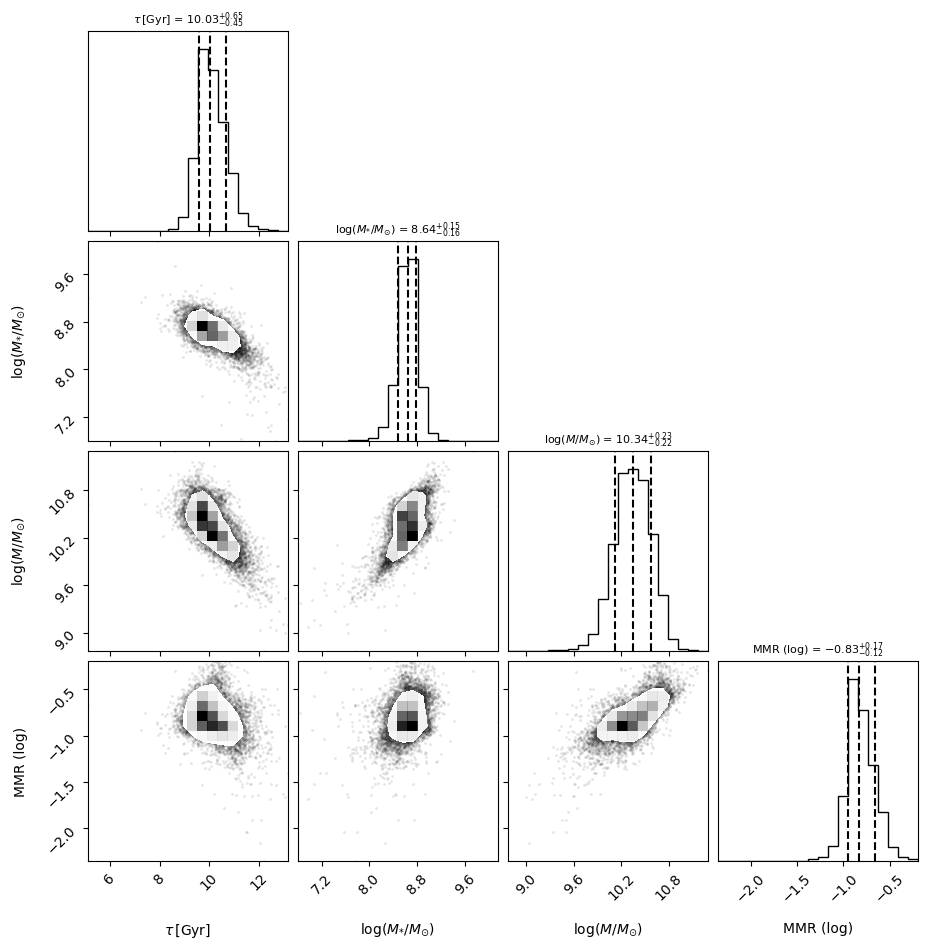

In [17]:
fig = corner.corner(posterior_samples, 
                        bins=20, 
                        labels=plot_labels,
                        quantiles=[.16,.50,.84],
                        plot_contours=False,
                        show_titles=True,
                        title_kwargs={'fontsize':8},
                        verbose=True)